1.Data Loading
2. Data Preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Download the Loan Prediction Dataset [cite: 29]
path = kagglehub.dataset_download("mosaadhendam/loan-prediction-dataset")

# List contents of the downloaded directory to find the actual CSV file
print(f"Contents of downloaded directory '{path}':")
downloaded_files = os.listdir(path)
for f_name in downloaded_files:
    print(f"- {f_name}")

# Try to find 'Training Data.csv' or a similar relevant CSV
file_name = None
for f_name in downloaded_files:
    if 'Training Data.csv' in f_name: # Check if the expected file name is in any of the files
        file_name = f_name
        break
# If 'Training Data.csv' is not found directly, take the first CSV file if any
if file_name is None:
    for f_name in downloaded_files:
        if f_name.endswith('.csv'):
            file_name = f_name
            break

if file_name is None:
    raise FileNotFoundError(f"No CSV file found in the downloaded dataset at {path}")

file_path = os.path.join(path, file_name)
print(f"Using file: {file_path}")

df = pd.read_csv(file_path)

# Display basic structure [cite: 84]
print("Dataset Shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'loan-prediction-dataset' dataset.
Contents of downloaded directory '/kaggle/input/loan-prediction-dataset':
- loan_prediction_dataset.csv
Using file: /kaggle/input/loan-prediction-dataset/loan_prediction_dataset.csv
Dataset Shape: (2000, 7)


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


3. Data Cleaning and Handling Missing Values

In [ ]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Simple Imputation: Fill numerical with median, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Convert Categorical to Numerical (Label Encoding)
# Focus on key features: Education, Marital Status, etc.
df = pd.get_dummies(df, drop_first=True)

print("\nData Cleaning Complete.")

4. Exploratory Data Analysis (EDA)

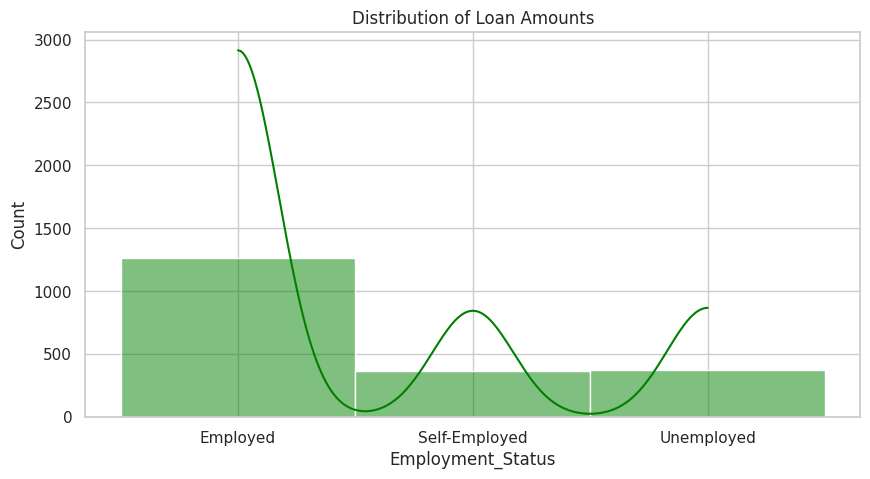

In [5]:
# Set visual style
sns.set(style="whitegrid")

# Visualize Loan Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df.iloc[:, 5], kde=True, color='green') # Using index if column names vary
plt.title('Distribution of Loan Amounts')
plt.show()

# Visualize Income vs Loan Default (Risk_Flag is usually the target)
# Note: Check your specific column name for the target (e.g., 'Risk_Flag')
target_col = 'Risk_Flag'
if target_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=target_col, data=df)
    plt.title('Loan Default (0 = No, 1 = Yes)')
    plt.show()

5. Model Training and Evaluation

Accuracy Score: 0.915

Confusion Matrix:
 [[311  11]
 [ 23  55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       322
           1       0.83      0.71      0.76        78

    accuracy                           0.92       400
   macro avg       0.88      0.84      0.86       400
weighted avg       0.91      0.92      0.91       400



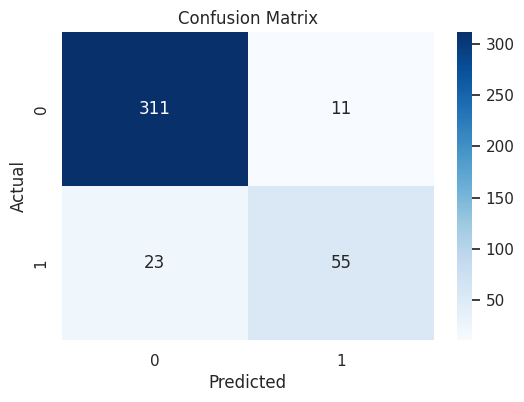

In [9]:
# Define Features (X) and Target (y)
target_col = 'Loan_Approved'

# Ensure categorical features are converted to numerical before splitting X and y
# This step is critical for models like Logistic Regression
df_processed = pd.get_dummies(df, drop_first=True)

X = df_processed.drop(target_col, axis=1)
y = df_processed[target_col]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression Model [cite: 33]
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics [cite: 34, 88]
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plotting Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()